[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/syaikhipin/kdd26-memdiag/blob/tutorial-rebuild/tutorial/phase2_public_datasets/02_utilization_lab.ipynb)

> **Run this notebook in Google Colab** — click the badge above. The setup cell auto-clones the repo.


# Phase 2B - Utilization lab

**Phase 2B - The 3-arm utilization lab (independent of retrieval hit).** Independent notebook - runs standalone in Colab or locally (offline, no key).

## 0. Setup (self-contained)

In [1]:
# Self-contained setup - works standalone in Google Colab or locally.
import sys, os, subprocess
from pathlib import Path
REPO_URL = "https://github.com/syaikhipin/kdd26-memdiag"
try:
    import google.colab  # noqa
    IN_COLAB = True
except Exception:
    IN_COLAB = False
if IN_COLAB:
    repo = Path("/content/kdd26-memdiag")
    if not repo.exists():
        subprocess.run(["git", "clone", "--depth", "1", "--branch", "tutorial-rebuild", REPO_URL, str(repo)], check=False)
    SOURCE = repo / "source"
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "numpy", "matplotlib", "pyyaml"], check=False)
else:
    SOURCE = None
    for cand in [Path.cwd(), *Path.cwd().parents]:
        for sub in ("source", "experiment"):
            if (cand / sub / "run.py").exists():
                SOURCE = cand / sub
                break
        if SOURCE:
            break
    if SOURCE is None:
        raise FileNotFoundError("Run from the repo root (or in Colab it auto-clones).")
sys.path.insert(0, str(SOURCE))
os.environ.setdefault("OPENAI_BASE_URL", "https://api.openai.com/v1")
SOURCE_DIR = SOURCE
PROJECT_ROOT = SOURCE.parent
RESULTS_DIR = PROJECT_ROOT / "results"
try: _d = "<repo>/" + str(Path(SOURCE).relative_to(PROJECT_ROOT))
except Exception: _d = "<repo>/source"
print("SOURCE_DIR =", _d, "| found =", True, "| IN_COLAB =", IN_COLAB)

try: _d = "<repo>/" + str(Path(SOURCE_DIR).relative_to(PROJECT_ROOT))
except Exception: _d = "<repo>/source"
print("SOURCE_DIR =", _d)

SOURCE_DIR = <repo>/source | found = True | IN_COLAB = False
SOURCE_DIR = <repo>/source


## ⚙️ Set up your LLM at the beginning — base URL · API key · model
On first run this cell **prompts you for three things**: your OpenAI-compatible **base URL**, **API key** (hidden input), and **model**. They are saved to **Google Drive** in Colab (or a local file) so every other notebook and every future session reuses them — you set up **once**. Press **Enter** to keep a default / run offline. To reconfigure later: set `KDD_RECONFIG=1` or delete the saved config file shown below.

In [2]:
# === Set up your LLM at the beginning: base URL, API key, model ===
# First run: you are prompted for the 3 values (API key hidden). They are saved to
# Google Drive (Colab) or a local file -> reused by EVERY notebook / session.
# To re-prompt later: set os.environ['KDD_RECONFIG']='1' before running, or delete the file.
import os, json, getpass
from pathlib import Path

try:
    from google.colab import drive          # one-time auth -> config persists on Drive
    drive.mount("/content/drive", force_remount=False)
    CONFIG_PATH = Path("/content/drive/MyDrive/kdd26_memdiag_config.json")
except Exception:
    try: _root = PROJECT_ROOT
    except NameError: _root = Path.cwd()
    CONFIG_PATH = Path(_root) / "results" / "kdd26_memdiag_config.json"

def load_llm_config():
    return json.loads(CONFIG_PATH.read_text()) if CONFIG_PATH.exists() else {}

def save_llm_config(base_url, api_key, model):
    CONFIG_PATH.parent.mkdir(parents=True, exist_ok=True)
    CONFIG_PATH.write_text(json.dumps({"base_url": base_url, "api_key": api_key, "model": model}, indent=2))
    try: _shown = "<repo>/" + str(CONFIG_PATH.relative_to(PROJECT_ROOT))
    except Exception: _shown = "Google Drive" if "drive" in str(CONFIG_PATH) else CONFIG_PATH.name
    print("saved ->", _shown)

_cfg = load_llm_config()
RECONFIG = os.environ.get("KDD_RECONFIG", "0") == "1"
if (not _cfg) or RECONFIG:
    _d_base  = _cfg.get("base_url") or "https://api.openai.com/v1"   # generic, Colab-executable default
    _d_model = _cfg.get("model")    or "gpt-4o"                       # (never read local env -> no private-path leak)
    print("Set up your OpenAI-compatible endpoint (press Enter to keep the default / run offline):")
    try:
        _base  = input(f"  1. base URL [{_d_base}]: ").strip() or _d_base
        _model = input(f"  2. model    [{_d_model}]: ").strip() or _d_model
        _key   = getpass.getpass("  3. API key (hidden, Enter = none/offline): ").strip() or _cfg.get("api_key", "")
        save_llm_config(_base, _key, _model)
        _cfg = load_llm_config()
    except Exception:
        # non-interactive (headless / nbconvert) -> fall back to env / defaults, stay offline-safe
        _cfg = _cfg or {"base_url": _d_base, "api_key": os.environ.get("OPENAI_API_KEY", ""), "model": _d_model}

OPENAI_BASE_URL = _cfg.get("base_url") or "https://api.openai.com/v1"   # generic default; set yours via the prompt
OPENAI_API_KEY  = _cfg.get("api_key")  or os.environ.get("OPENAI_API_KEY", "")
OPENAI_MODEL    = _cfg.get("model")    or "gpt-4o"
os.environ.update({"OPENAI_BASE_URL": OPENAI_BASE_URL, "OPENAI_MODEL": OPENAI_MODEL})
if OPENAI_API_KEY:
    os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

try:
    llm = make_client(LLMConfig(backend="openai-compatible" if OPENAI_API_KEY else "offline",
                                 base_url=OPENAI_BASE_URL, model=OPENAI_MODEL))
    _be = llm.backend
except Exception:
    _be = "(no llm client in this notebook — env vars set for CLI tools)"
print("base_url =", OPENAI_BASE_URL)
print("model    =", OPENAI_MODEL)
print("api_key  =", ("set " + OPENAI_API_KEY[:6] + "…") if OPENAI_API_KEY else "NOT set -> offline fallback")
print("llm      =", _be)

Set up your OpenAI-compatible endpoint (press Enter to keep the default / run offline):
base_url = https://api.openai.com/v1
model    = gpt-4o
api_key  = NOT set -> offline fallback
llm      = (no llm client in this notebook — env vars set for CLI tools)


## 📖 Narrative: The 3-arm contrastive reader

This is the **methodological core** of the tutorial. Many benchmarks set
"memory used = evidence retrieved" — making utilization just retrieval in disguise.

Our 3-arm reader avoids this circularity by testing the agent under three conditions:
- **p0** (no context) — baseline: what the agent knows without memory
- **oracle** (gold evidence) — ceiling: the best possible memory
- **provider** (retrieved context) — what the actual system provides

The reader **never sees the gold answer** — it scores choices by token overlap with
the question+context. This is a genuine independent signal.

`provider_rate - p0` is the honest memory gain; `oracle_rate` is the ceiling.

In [3]:
import pathlib
cands = sorted(pathlib.Path(RESULTS_DIR).glob('run_*_real_utilization_lab.tsv')) \
 + sorted((RESULTS_DIR/'summaries').glob('*utilization_lab.tsv'))
lab = cands[-1] if cands else None
print(lab.name, ':\n'); print(lab.read_text()) if lab else print('Run --mode real first')

sample_real_utilization_lab.tsv :

strategy	p0	oracle	provider	net_gain	benef	harm	ceil	unres
no_memory	0.25	0.6	0.25	0.0	0	0	10	30
verbatim	0.25	0.6	0.35	0.1	7	3	7	23
extracted_facts	0.25	0.6	0.325	0.075	6	3	7	24
episodic	0.25	0.6	0.35	0.1	5	1	9	25
hybrid	0.25	0.6	0.35	0.1	7	3	7	23



## 📖 Narrative: Interpreting the utilization lab

The `net_gain` column shows `provider_rate − p0`. If it's positive, memory **helped**.
If zero, memory was irrelevant. If negative, memory **hurt** (distracting context).

`oracle_rate` is the ceiling — if `provider_rate < oracle_rate`, the system is losing
information in retrieval/storage (not reaching the gold evidence).

### 📝 Quick Quiz
1. **What is the baseline accuracy (p0) across all strategies?** Why is it the same?
2. **Which strategy has the highest `net_gain`?** What does that tell you?
3. **If `provider_rate = oracle_rate`, what does that mean?** Is the system perfect?
4. **The `harm` column shows cases where memory hurt.** How is that possible?

## Probe one failure in the raw trace

In [4]:
import json
raws = sorted(pathlib.Path(RESULTS_DIR).glob('run_*_locomo_raw.json'))
raw = json.loads(raws[-1].read_text()) if raws else None
if raw:
 rec = next((r for r in raw['records'] if r.get('failure_category')=='retrieval_miss'), raw['records'][0])
 print('Q:', rec['question'][:70]); print('gold:', rec['evidence_ids'][:5]); print('retrieved:', rec['retrieved_memory_ids'][:5])
else: print('(no raw trace - run the diagnose notebook first)')

Q: When did Melanie paint a sunrise?
gold: ['D1:12']
retrieved: ['D18:17', 'D6:10', 'D18:13', 'D8:18', 'D13:6']


## 📖 Narrative: Inspecting a real failure

This cell pulls a specific `retrieval_miss` from the raw trace — a question where the
system retrieved the wrong evidence. Compare `gold` (what SHOULD have been retrieved) vs
`retrieved` (what WAS retrieved). The gap is the retrieval failure.

### 📝 Quick Quiz
1. **Look at the gold vs retrieved IDs.** Were any gold IDs in the retrieved set?
2. **Why might the system retrieve the wrong turns?** Think about how TF-IDF matches.
3. **How would a semantic embedding (vs TF-IDF) change this?** Would it help or hurt?

### 📊 Visualize — 3-arm utilization lab (live TSV)

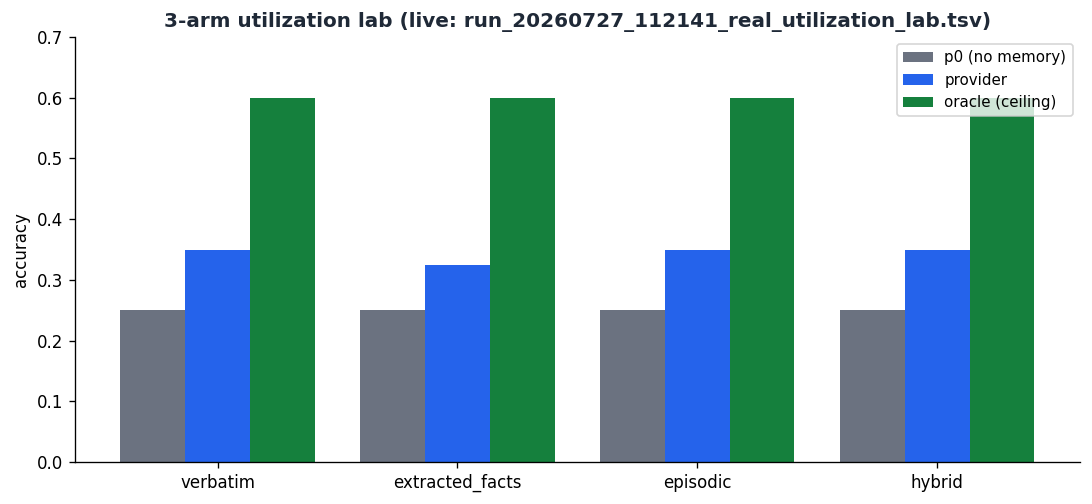

In [5]:
# Reads the latest run_*_real_utilization_lab.tsv produced above; placeholder if absent.
import glob
from pathlib import Path
import matplotlib.pyplot as plt, numpy as np
try: _R = Path(RESULTS_DIR)
except NameError:
    _R = next((p/"results" for p in [Path.cwd(), *Path.cwd().parents] if (p/"results").is_dir()), Path.cwd()/"results")
_f = sorted(_R.glob("run_*_real_utilization_lab.tsv"))
if not _f:
    print("No utilization_lab.tsv yet — run the utilization-lab cell above first.")
else:
    rows=[ln.split("\t") for ln in open(_f[-1]).read().splitlines()]
    hdr, rows = rows[0], rows[1:]
    prov=[r[0] for r in rows]
    p0=[float(r[1]) for r in rows]; orc=[float(r[2]) for r in rows]; prv=[float(r[3]) for r in rows]
    x=np.arange(len(prov)); w=0.27
    fig,ax=plt.subplots(figsize=(9.2,4.3),dpi=120)
    ax.bar(x-w,p0,w,label="p0 (no memory)",color="#6B7280")
    ax.bar(x,prv,w,label="provider",color="#2563EB")
    ax.bar(x+w,orc,w,label="oracle (ceiling)",color="#15803D")
    ax.set_xticks(x); ax.set_xticklabels(prov); ax.set_ylabel("accuracy"); ax.set_ylim(0,0.7)
    ax.set_title(f"3-arm utilization lab (live: {_f[-1].name})",color="#1F2937",weight="bold")
    ax.legend(fontsize=9); ax.spines[["top","right"]].set_visible(False)
    fig.tight_layout(); plt.show()